In [ ]:
from pathlib import Path
import re
import unicodedata
import pandas as pd

BASE = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
RAW_NAMES = [
    'SA2 Coverage Indicators.xlsx', '32180DS0001_2024-25.xlsx',
    'mobile-coverage-all-sites.xlsx', 'FN-home.xlsx',
]
DATA = BASE if all((BASE / name).exists() for name in RAW_NAMES) else BASE / 'data'
OUT = BASE / 'output'
FILES = {
    'coverage': DATA / 'SA2 Coverage Indicators.xlsx',
    'population': DATA / '32180DS0001_2024-25.xlsx',
    'mobile_2022': DATA / 'mobile-coverage-all-sites.xlsx',
    'inclusion': DATA / 'FN-home.xlsx',
}
missing = [str(path) for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Put the four raw files beside the script or in its data folder:\n'
                            + '\n'.join(missing))

LOOKUP = next((p for p in [DATA / 'NT_Community_SA2_Reference.xlsx',
                          BASE / 'NT_Community_SA2_Reference.xlsx'] if p.exists()), None)

print('SOURCE INSPECTION')
for label, path in FILES.items():
    book = pd.ExcelFile(path)
    print(f'{label}: {path.name} | sheets: {book.sheet_names}')
print('Community lookup:', LOOKUP.name if LOOKUP else 'not found (optional for sections 1–6)')

In [ ]:
# 2. Cleaning the SA2 connectivity dataset (one row per region)
coverage_raw = pd.read_excel(FILES['coverage'], sheet_name='Sheet 1', dtype={'SA2_code': str})
coverage_columns = {
    'SA2_name': 'sa2_name',
    'SA2_code': 'sa2_code',
    '4G_5G_premises_indicator': 'mobile_premises_pct',
    '4G_5G_area_indicator': 'mobile_area_pct',
    'NBN_fixed_premises_indicator': 'nbn_fixed_premises_pct',
    'NBN_satellite_premises_indicator': 'nbn_satellite_premises_pct',
}
coverage = coverage_raw[list(coverage_columns)].rename(columns=coverage_columns).copy()
coverage['sa2_code'] = coverage['sa2_code'].astype('string').str.strip()
coverage = coverage[coverage['sa2_code'].str.startswith('7', na=False)].copy()
for col in [c for c in coverage if c.endswith('_pct')]:
    coverage[col] = pd.to_numeric(coverage[col], errors='coerce')

print('\nCOVERAGE CLEANING')
print('All source rows:', len(coverage_raw), '| NT rows:', len(coverage))
print('Missing cells:\n', coverage.isna().sum().to_string())
print('Repeated SA2 codes:', coverage['sa2_code'].duplicated().sum())
print(coverage.head(4).to_string(index=False))
assert coverage['sa2_code'].is_unique
assert coverage[[c for c in coverage if c.endswith('_pct')]].apply(
    lambda s: s.between(0, 100).all()
).all()

In [ ]:
# 3. Extracting 2025 population from ABS Table 7 (multi-row header)
abs_raw = pd.read_excel(FILES['population'], sheet_name='Table 7', header=None)
# In this ABS file, the header is on Excel row 6 (pandas index 5), so data
# starts at pandas index 6. Columns G,H,J,P,Q hold the fields below.
population = abs_raw.iloc[6:, [6, 7, 9, 15, 16]].copy()
population.columns = ['sa2_code', 'abs_sa2_name', 'population_2025',
                      'area_km2', 'population_density_2025']
population['sa2_code'] = population['sa2_code'].astype('string').str.replace(
    r'\.0$', '', regex=True
).str.strip()
population = population[population['sa2_code'].str.fullmatch(r'\d{9}', na=False)].copy()
for col in ['population_2025', 'area_km2', 'population_density_2025']:
    population[col] = pd.to_numeric(population[col], errors='coerce')

print('\nABS CLEANING')
print('Extracted SA2 rows:', len(population), '| missing:\n',
      population.isna().sum().to_string())
print(population.head(4).to_string(index=False))
assert population['sa2_code'].is_unique
assert population['population_2025'].notna().all()

In [ ]:
# 4. Validate the SA2 key and perform the main merge
only_coverage = sorted(set(coverage.sa2_code) - set(population.sa2_code))
only_population = sorted(set(population.sa2_code) - set(coverage.sa2_code))
master = coverage.merge(population, on='sa2_code', how='outer',
                        validate='one_to_one', indicator=True)
print('\nSA2 JOIN AUDIT')
print('Coverage-only SA2 codes:', only_coverage)
print('Population-only SA2 codes:', only_population)
print(master['_merge'].value_counts(dropna=False).to_string())
name_disagreement = master[master['sa2_name'] != master['abs_sa2_name']]
print('SA2 name differences:', len(name_disagreement))
assert (master['_merge'] == 'both').all(), 'Investigate unmatched SA2 codes'
assert len(master) == 68, 'Investigate unexpected NT SA2 count'
master = master.drop(columns='_merge').sort_values('sa2_code').reset_index(drop=True)
print(master[['sa2_code', 'sa2_name', 'population_2025',
              'mobile_premises_pct', 'nbn_fixed_premises_pct']].head(8).to_string(index=False))

In [ ]:
# 5. Inspecting the historical mobile-sites file; preserving its date/meaning
mobile_raw = pd.read_excel(FILES['mobile_2022'],
                           sheet_name='Communities with Mobile', header=4)
mobile_raw.columns = mobile_raw.columns.astype(str).str.strip()
print('\nHISTORICAL MOBILE SITE TYPES')
print(mobile_raw['SITE TYPE'].value_counts(dropna=False).to_string())
mobile = mobile_raw[mobile_raw['SITE TYPE'].astype('string').str.strip().str.upper()
                    .eq('COMMUNITY')].copy()
mobile = mobile.rename(columns={
    'SITE NAME': 'historical_site_name', 'MACRO CELL': 'macro_cell_2022',
    'SMALL CELL': 'small_cell_2022', 'PROXIMITY TO CELL': 'near_cell_2022',
    'PROVIDER': 'provider_2022',
})[['historical_site_name', 'macro_cell_2022', 'small_cell_2022',
     'near_cell_2022', 'provider_2022']]

def name_key(value):
    """Conservative matching aid; review aliases instead of fuzzy guessing."""
    cleaned = unicodedata.normalize('NFKD', str(value)).upper()
    return re.sub(r'[^A-Z0-9]', '', cleaned)

mobile['name_key'] = mobile['historical_site_name'].map(name_key)
print('2022 community rows:', len(mobile),
      '| duplicate cleaned names:', mobile['name_key'].duplicated().sum())
assert mobile['name_key'].is_unique

In [ ]:
#  6. Extracting ONLY contextual digital inclusion indicators
fn_raw = pd.read_excel(FILES['inclusion'], sheet_name='Export', header=None)
labels = fn_raw.iloc[:, 0].astype('string').str.strip()
snapshot_start = labels[labels.eq('National snapshot')].index[0]
breakdown_start = labels[labels.eq('Breakdown')].index[0]
access_start = labels[labels.eq('Access')].index[0]
nt_row = fn_raw.iloc[snapshot_start:breakdown_start]
nt_row = nt_row[nt_row.iloc[:, 0].astype('string').str.strip().eq('NT')]
remoteness = fn_raw.iloc[breakdown_start:access_start]
remoteness = remoteness[remoteness.iloc[:, 0].astype('string').str.strip()
                        .isin(['Remote', 'Very Remote'])]
inclusion_context = pd.concat([nt_row, remoteness]).iloc[:, :2].copy()
inclusion_context.columns = ['geographic_summary', 'adii_score']
inclusion_context['adii_score'] = pd.to_numeric(inclusion_context['adii_score'])
print('\nFIRST NATIONS DIGITAL INCLUSION: CONTEXT ONLY')
print(inclusion_context.to_string(index=False))

NT row is a territory summary; Remote and Very Remote are remoteness summaries. They do not give scores for individual NT SA2s or communities

In [ ]:
#  7. matching 96 BushTel entries to 16 SA2s
community_view = None
if LOOKUP is not None:
    community = pd.read_excel(LOOKUP, sheet_name='Communities',
                              header=6, usecols='A:J', nrows=96,
                              dtype={'SA2 code': str})
    community = community.rename(columns={
        'BushTel ID': 'bushtel_id', 'Community': 'community',
        'BushTel type': 'community_type', 'Latitude': 'latitude',
        'Longitude': 'longitude', 'SA2 code': 'sa2_code',
        'SA2 name': 'community_sa2_name', 'Join status': 'join_status',
        'BushTel profile URL': 'bushtel_profile_url', 'Aliases': 'aliases',
    })
    community['sa2_code'] = community['sa2_code'].astype('string').str.strip()
    assert community['bushtel_id'].is_unique
    assert community['join_status'].eq('matched').all()

    community_view = community.merge(master, on='sa2_code', how='left',
                                     validate='many_to_one', indicator=True)
    print('\nCOMMUNITY → REGIONAL SA2 JOIN')
    print('BushTel Major/Minor entries:', len(community_view))
    print('Distinct containing SA2s:', community_view['sa2_code'].nunique())
    print(community_view['_merge'].value_counts(dropna=False).to_string())
    assert community_view['_merge'].eq('both').all()
    community_view = community_view.drop(columns='_merge')
    print(community_view.loc[community_view.community.eq('Yuendumu'),
          ['community', 'sa2_code', 'sa2_name']].to_string(index=False))
else:
    print('Section 7 skipped: add NT_Community_SA2_Reference.xlsx when ready.')

In [ ]:
#  8. Comparing with the 2022 list cautiously; inspecting nonmatches
if community_view is not None:
    community_view['name_key'] = community_view['community'].map(name_key)
    assert community_view['name_key'].is_unique
    community_view = community_view.merge(mobile, on='name_key', how='left',
                                         validate='one_to_one', indicator='historical_match')
    community_view['historical_listed_2022'] = community_view['historical_match'].eq('both')
    print('\n2022 MOBILE NAME MATCH REVIEW')
    print(community_view['historical_match'].value_counts(dropna=False).to_string())
    print('Examples requiring name/alias review:')
    print(community_view.loc[~community_view.historical_listed_2022,
          ['community', 'aliases']].head(15).to_string(index=False))
else:
    print('Section 8 skipped: the community lookup is optional for now.')

In [ ]:
#  9. Exporting the files
OUT.mkdir(parents=True, exist_ok=True)
master.to_csv(OUT / 'nt_sa2_master.csv', index=False)
if community_view is not None:
    community_view.drop(columns='name_key').to_csv(
        OUT / 'community_regional_context.csv', index=False)
inclusion_context.to_csv(OUT / 'digital_inclusion_context.csv', index=False)
print('\nFILES CREATED BY THIS PYTHON RUN:')
for path in sorted(OUT.glob('*.csv')):
    print(f'{path.name}: {len(pd.read_csv(path))} rows')


In [ ]:
#  10. Selecting candidate SA2s containing mapped communities
community_counts = (
    community_view.groupby('sa2_code')['bushtel_id']
    .nunique()
    .rename('mapped_communities')
    .reset_index()
)

candidate_sa2 = master.merge(
    community_counts,
    on='sa2_code',
    how='inner',
    validate='one_to_one'
)

print('NT SA2s in master:', len(master))
print('Candidate SA2s:', len(candidate_sa2))
print(
    candidate_sa2[
        ['sa2_name', 'mapped_communities', 'population_2025',
         'mobile_premises_pct', 'mobile_area_pct', 'nbn_fixed_premises_pct']
    ].sort_values('mapped_communities', ascending=False).to_string(index=False)
)

Katherine’s 11,269 people are the population of the whole SA2, not just its two mapped communities.
0% NBN fixed and 100% NBN satellite indicate different technology availability.
 A zero for fixed service does not mean no broadband option.
 The source measures availability, not service performance.

In [ ]:
#  11. Exploring the candidate SA2 indicators
indicators = [
    'mobile_premises_pct',
    'mobile_area_pct',
    'nbn_fixed_premises_pct',
    'nbn_satellite_premises_pct',
    'population_2025'
]

print(candidate_sa2[indicators].describe().round(1))

print(
    candidate_sa2[['sa2_name'] + indicators]
    .sort_values('mobile_premises_pct')
    .to_string(index=False)
)

In [ ]:
#  12. Turning coverage into regional gap indicators
candidate_sa2 = candidate_sa2.copy()

candidate_sa2['mobile_premises_gap'] = (
    100 - candidate_sa2['mobile_premises_pct']
)
candidate_sa2['nbn_fixed_gap'] = (
    100 - candidate_sa2['nbn_fixed_premises_pct']
)

print('SA2s with 0% NBN fixed availability:',
      (candidate_sa2['nbn_fixed_premises_pct'] == 0).sum())

print(
    candidate_sa2[
        ['sa2_name', 'mobile_premises_gap', 'nbn_fixed_gap',
         'mobile_area_pct', 'nbn_satellite_premises_pct']
    ]
    .sort_values('mobile_premises_gap', ascending=False)
    .head(8)
    .to_string(index=False)
)

In [ ]:
# 13. Trial scores and weight sensitivity
scores = candidate_sa2.copy()

weights = {
    '50_50': (0.50, 0.50),
    '60_40': (0.60, 0.40),
    '70_30': (0.70, 0.30),
}

for label, (mobile_weight, fixed_weight) in weights.items():
    scores[f'score_{label}'] = (
        mobile_weight * scores['mobile_premises_gap']
        + fixed_weight * scores['nbn_fixed_gap']
    )

print(
    scores[
        ['sa2_name', 'mobile_premises_gap', 'nbn_fixed_gap',
         'score_50_50', 'score_60_40', 'score_70_30']
    ]
    .sort_values('score_60_40', ascending=False)
    .head(10)
    .round(1)
    .to_string(index=False)
)

In [ ]:
# 14. Comparing ranks across the three trial weights
for label in weights:
    scores[f'rank_{label}'] = (
        scores[f'score_{label}']
        .rank(ascending=False, method='min')
        .astype(int)
    )

print(
    scores[
        ['sa2_name', 'rank_50_50', 'rank_60_40', 'rank_70_30']
    ]
    .sort_values('rank_60_40')
    .to_string(index=False)
)

print(
    'SA2s whose rank changes between 50/50 and 70/30:',
    (scores['rank_50_50'] != scores['rank_70_30']).sum()
)

In [19]:
#  15. List communities in the five highest-gap SA2s
top_regions = scores.sort_values(
    'score_60_40', ascending=False
).head(5)

for _, region in top_regions.iterrows():
    names = sorted(
        community_view.loc[
            community_view['sa2_code'] == region['sa2_code'],
            'community'
        ].tolist()
    )
    print(f"\n{region['sa2_name']} — trial regional score "
          f"{region['score_60_40']:.1f}/100")
    print("Communities to investigate:", ", ".join(names))


Victoria River — trial regional score 65.8/100
Communities to investigate: Amanbidji, Bulla, Daguragu, Kalkarindji, Lajamanu, Nitjpurru, Yarralin

Barkly — trial regional score 62.8/100
Communities to investigate: Ali Curung, Alpurrurulam, Canteen Creek, Imangara, Likkaparta, Marlinja, Mungkarta, Tara, Wutunugurra

Tanami — trial regional score 59.2/100
Communities to investigate: Areyonga, Haasts Bluff, Hermannsburg, Kintore, Mount Liebig, Nyirripi, Papunya, Wallace Rockhole

Sandover - Plenty — trial regional score 58.0/100
Communities to investigate: Amoonguna, Ampilatwatja, Arawerr, Atitjere, Engawala, Irrultja, Iwupataka, Orrtipa-Thurra, Santa Teresa, Titjikala

West Arnhem — trial regional score 56.2/100
Communities to investigate: Gochan Jiny Jirra, Gunbalanya, Maningrida, Manmoyi, Minjilang, Warruwi


In [20]:
# 16. Auditing historical name matches in the five highest-gap SA2s
review = community_view[
    community_view['sa2_code'].isin(top_regions['sa2_code'])
].copy()

audit = review.groupby('sa2_name', as_index=False).agg(
    communities=('community', 'size'),
    direct_2022_name_matches=('historical_listed_2022', 'sum')
)
audit['without_direct_name_match'] = (
    audit['communities'] - audit['direct_2022_name_matches']
)

print("2022 NAME-MATCH AUDIT")
print(audit.to_string(index=False))

print("\nCommunities without a direct 2022 name match:")
print(
    review.loc[
        ~review['historical_listed_2022'],
        ['sa2_name', 'community', 'aliases']
    ].sort_values(['sa2_name', 'community']).to_string(index=False)
)

2022 NAME-MATCH AUDIT
         sa2_name  communities  direct_2022_name_matches  without_direct_name_match
           Barkly            9                         3                          6
Sandover - Plenty           10                         6                          4
           Tanami            8                         5                          3
   Victoria River            7                         5                          2
      West Arnhem            6                         4                          2

Communities without a direct 2022 name match:
         sa2_name         community                                                                                 aliases
           Barkly     Canteen Creek                                                     ORWAITILLYA, ORWAITILLA, OWAIRTILLA
           Barkly          Imangara                                 MURRY DOWNS, IMANGARRA, MURRAY DOWNS, IMANGARA MUNGARAI
           Barkly        Likkaparta                    

In [22]:
# 17. Exporting trial SA2 results for review
community_counts = community_view.groupby('sa2_code', as_index=False).agg(
    mapped_communities=('bushtel_id', 'size'),
    direct_2022_name_matches=('historical_listed_2022', 'sum')
)

regional_screening = (
    scores.drop(
        columns=['mapped_communities', 'direct_2022_name_matches'],
        errors='ignore'
    )
    .merge(community_counts, on='sa2_code', validate='one_to_one')
    .sort_values(['rank_60_40', 'sa2_name'])
)

assert len(regional_screening) == 16
assert regional_screening['mapped_communities'].sum() == 96

columns = [
    'rank_60_40', 'sa2_code', 'sa2_name',
    'mobile_premises_gap', 'nbn_fixed_gap',
    'score_50_50', 'score_60_40', 'score_70_30',
    'mapped_communities', 'direct_2022_name_matches'
]

regional_screening[columns].to_csv(
    OUT / 'trial_sa2_regional_screening.csv', index=False
)

print(regional_screening[columns].to_string(index=False))
print("\nSaved: trial_sa2_regional_screening.csv")

 rank_60_40  sa2_code             sa2_name  mobile_premises_gap  nbn_fixed_gap  score_50_50  score_60_40  score_70_30  mapped_communities  direct_2022_name_matches
          1 702051068       Victoria River                   43            100         71.5         65.8         60.1                   7                         5
          2 702021055               Barkly                   38            100         69.0         62.8         56.6                   9                         3
          3 702011053               Tanami                   32            100         66.0         59.2         52.4                   8                         5
          4 702011052    Sandover - Plenty                   30            100         65.0         58.0         51.0                  10                         6
          5 702031061          West Arnhem                   27            100         63.5         56.2         48.9                   6                         4
          6 7020

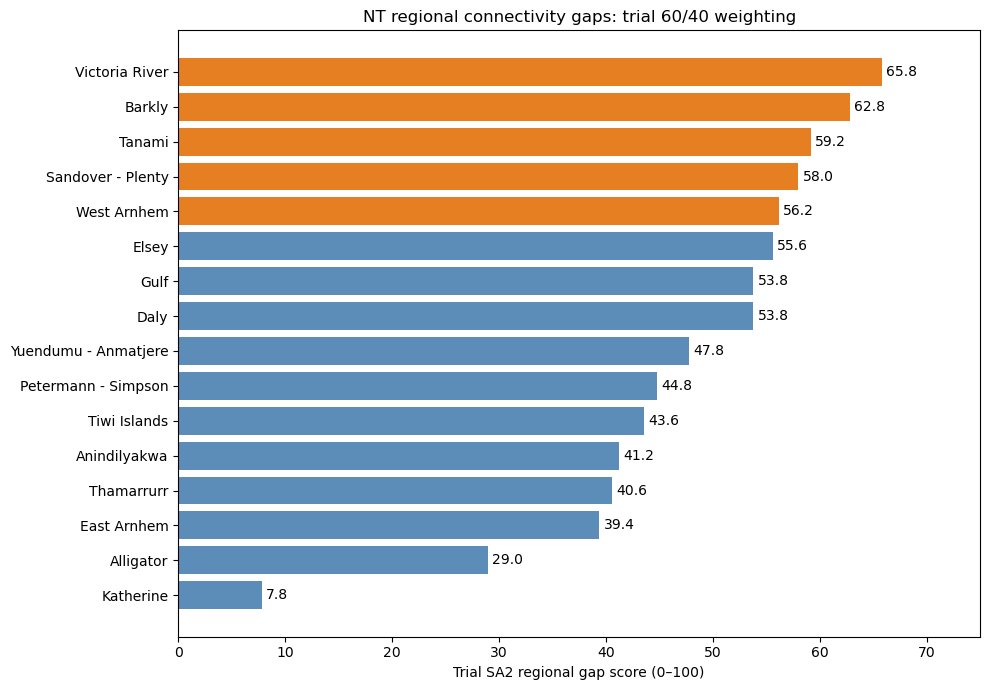

In [23]:
# 18. Visualising the trial regional scores
import matplotlib.pyplot as plt

plot_data = regional_screening.sort_values('score_60_40')
top_five_codes = set(top_regions['sa2_code'])

colors = [
    '#e67e22' if code in top_five_codes else '#5b8db8'
    for code in plot_data['sa2_code']
]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_data['sa2_name'], plot_data['score_60_40'],
               color=colors)

ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlim(0, 75)
ax.set_xlabel('Trial SA2 regional gap score (0–100)')
ax.set_title('NT regional connectivity gaps: trial 60/40 weighting')

plt.tight_layout()
plt.savefig(OUT / 'trial_sa2_regional_scores.png',
            dpi=200, bbox_inches='tight')
plt.show()

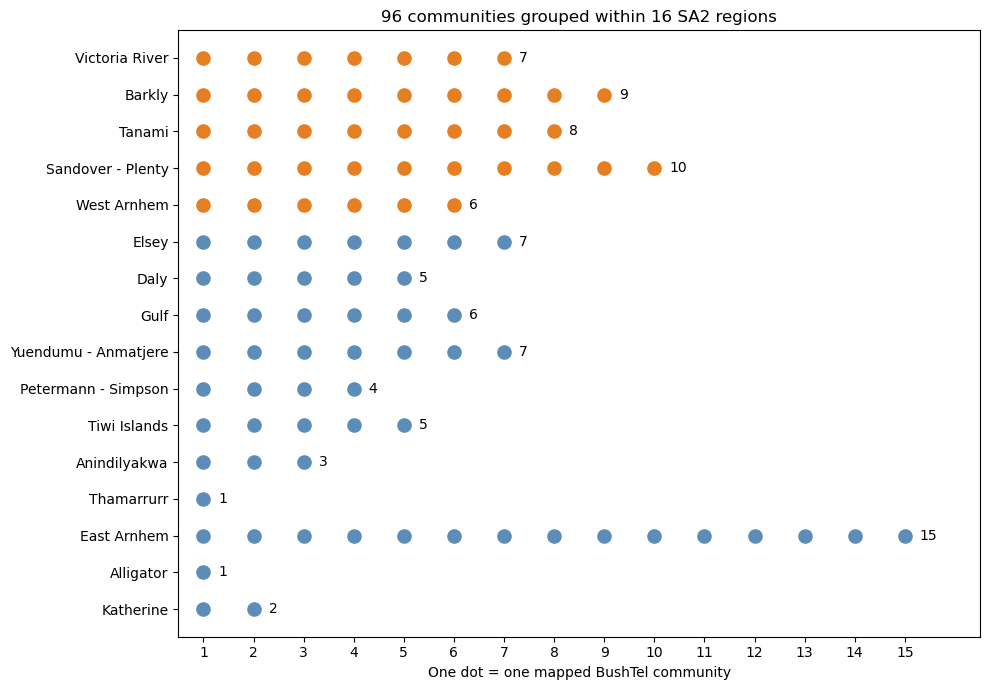

In [24]:
# 19. Showing communities nested within SA2 regions
fig, ax = plt.subplots(figsize=(10, 7))

for y, (_, region) in enumerate(regional_screening.iterrows()):
    communities = community_view.loc[
        community_view['sa2_code'] == region['sa2_code'], 'community'
    ].tolist()

    color = '#e67e22' if region['rank_60_40'] <= 5 else '#5b8db8'
    ax.scatter(range(1, len(communities) + 1),
               [y] * len(communities), s=90, color=color)
    ax.text(len(communities) + 0.3, y, str(len(communities)),
            va='center')

ax.set_yticks(range(len(regional_screening)),
              regional_screening['sa2_name'])
ax.invert_yaxis()
ax.set_xticks(range(1, 16))
ax.set_xlim(0.5, 16.5)
ax.set_xlabel('One dot = one mapped BushTel community')
ax.set_title('96 communities grouped within 16 SA2 regions')

plt.tight_layout()
plt.savefig(OUT / 'communities_within_sa2s.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [25]:
# Interactive version: hover over a dot to see its community name
import plotly.express as px

points = community_view[
    ['sa2_code', 'sa2_name', 'community']
].sort_values(['sa2_name', 'community']).copy()

points['dot_position'] = points.groupby('sa2_code').cumcount() + 1
ranks = regional_screening.set_index('sa2_code')['rank_60_40']
points['group'] = points['sa2_code'].map(ranks).le(5).map({
    True: 'Five highest scoring SA2s',
    False: 'Other SA2s'
})

fig = px.scatter(
    points,
    x='dot_position',
    y='sa2_name',
    color='group',
    hover_name='community',
    hover_data={'sa2_name': True, 'dot_position': False, 'group': False},
    category_orders={
        'sa2_name': regional_screening['sa2_name'].tolist()
    },
    color_discrete_map={
        'Five highest scoring SA2s': '#e67e22',
        'Other SA2s': '#5b8db8'
    },
    title='BushTel communities grouped within SA2 regions'
)

fig.update_traces(marker_size=13)
fig.update_yaxes(autorange='reversed', title='')
fig.update_xaxes(dtick=1, title='One dot = one community')
fig.update_layout(height=750)
fig.write_html(OUT / 'communities_within_sa2s_interactive.html')
fig.show()